In [1]:
import numpy as np 
import pickle 
import h5py
from scipy import stats
from tqdm.auto import tqdm
from pathlib import Path 

import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import src.util_analysis as util_analysis

## Plot main model, alternate models, and control models 

Using `v09` models

In [28]:
# Get model activation files 

out_dir = Path('binaural_model_attn_stage_reps/')
# paths = list(out_dir.glob('*model_activations_0dB.h5'))

# path  = Path("binaural_model_attn_stage_reps/word_task_half_co_loc_v07_model_activations_0dB.h5")
# path  = Path("binaural_model_attn_stage_reps/word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout/word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout_model_activations_0dB_w_cues_and_corrs_v3.h5")
paths = list(out_dir.rglob('*v09*_model_activations_0dB_w_cues_and_corrs_v3.h5'))
paths

[PosixPath('binaural_model_attn_stage_reps/word_task_early_only_v09/word_task_early_only_v09_model_activations_0dB_w_cues_and_corrs_v3.h5'),
 PosixPath('binaural_model_attn_stage_reps/word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout/word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout_model_activations_0dB_w_cues_and_corrs_v3.h5'),
 PosixPath('binaural_model_attn_stage_reps/word_task_late_only_v09/word_task_late_only_v09_model_activations_0dB_w_cues_and_corrs_v3.h5')]

In [14]:
outfig_dest = Path('manuscript/figures')
outfig_dest.mkdir(parents=True, exist_ok=True)

### Correlations pre-computed

Load for wanted analysis: 
* corr(target_no_cue, mixture)
* corr(distractor_no_cue, mixture)

Will also load pre-computed cosine similarity

In [30]:
paths[0].parent.name

'word_task_early_only_v09'

In [37]:
corr_dfs = []
cos_dfs = []

for path in paths:
    with h5py.File(path, 'r') as acts:
        ## Get keys with corr in them 
        layer_names = sorted(set([key.split("_fg")[0] for key in acts.keys() if "fg" in key])) # set to remove duplicates 
        print(layer_names)

        dfs = []
        for layer in layer_names:
            data_dict = {}

            if layer != 'cochleagram':
                # get values for uncued single source vs cued mixture
                data_dict['fg_corrs'] = acts[f"{layer}_fg_mixture_corr_no_cue"][:, 0]
                data_dict['bg_corrs'] = acts[f"{layer}_bg_mixture_corr_no_cue"][:, 0]
                data_dict['fg_cos'] = acts[f"{layer}_fg_mixture_cos_no_cue"][:]
                data_dict['bg_cos'] = acts[f"{layer}_bg_mixture_cos_no_cue"][:]
            elif layer == 'cochleagram':
                # get values for single source vs mixture cochleagrams
                data_dict['fg_corrs'] = acts[f"{layer}_fg_mixture_corr"][:, 0]
                data_dict['bg_corrs'] = acts[f"{layer}_bg_mixture_corr"][:, 0]
                data_dict['fg_cos'] = acts[f"{layer}_fg_mixture_cos"][:]
                data_dict['bg_cos'] = acts[f"{layer}_bg_mixture_cos"][:]

            data_dict['layer'] = [layer]*len(acts[f"{layer}_fg_mixture_corr"])

            df = pd.DataFrame(data_dict)
            df['model_name'] = util_analysis.model_name_dict[path.parent.name]
            dfs.append(df)
    act_results  = pd.concat(dfs)

    act_results['layer'] = act_results['layer'].str.replace('_block_', '')

    act_corrs = pd.melt(act_results[[col for col in act_results.columns if 'cos' not in col]], id_vars =['layer', 'model_name'], value_vars=['fg_corrs', 'bg_corrs'], var_name='Stream',
                                value_name="Pearson's r")
    act_cos = pd.melt(act_results[[col for col in act_results.columns if 'corr' not in col]], id_vars =['layer', 'model_name'], value_vars=['fg_cos', 'bg_cos'], var_name='Stream',
                                value_name="Cosine similarity")

    # merge 

    act_corrs['Stream'].replace('fg_corrs','corr(target$_i$, mixture$_i$)',inplace=True)
    act_corrs['Stream'].replace('bg_corrs','corr(distractor$_i$, mixture$_i$)',inplace=True)

    # same as above but cos instead of corrs 
    act_cos['Stream'].replace('fg_cos', 'sim(target$_i$, mixture$_i$)', inplace=True)
    act_cos['Stream'].replace('bg_cos', 'sim(distractor$_i$, mixture$_i$)', inplace=True)

    act_corrs['layer'].replace('cochleagram','cochlea',inplace=True)

    corr_dfs.append(act_corrs)
    cos_dfs.append(act_cos)

corr_results = pd.concat(corr_dfs, ignore_index=True, axis=0)
cos_results = pd.concat(cos_dfs, ignore_index=True, axis=0)


['cochleagram', 'conv_block_0', 'conv_block_1', 'conv_block_2', 'conv_block_3', 'conv_block_4', 'conv_block_5', 'conv_block_6', 'relufc']
['cochleagram', 'conv_block_0', 'conv_block_1', 'conv_block_2', 'conv_block_3', 'conv_block_4', 'conv_block_5', 'conv_block_6', 'relufc']
['cochleagram', 'conv_block_0', 'conv_block_1', 'conv_block_2', 'conv_block_3', 'conv_block_4', 'conv_block_5', 'conv_block_6', 'relufc']


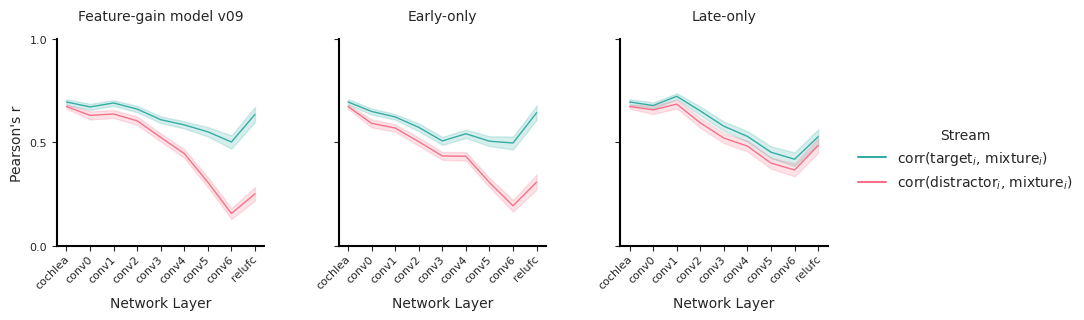

In [61]:
## Plot summary_results df 
sns.set_style('ticks')
# order = np.sort(results.layer.unique())
plt.rc('font', family='Helvetica')

hue_order = ['corr(target$_i$, mixture$_i$)', 'corr(distractor$_i$, mixture$_i$)', ]#'corr(target$_i$, target$_j$)', 'corr(target$_i$, mixture$_j$)']
# make palette for models in husl 
palette = sns.color_palette("husl", 2)
# make palette dict 
palette_dict = {'corr(target$_i$, mixture$_i$)': palette[1],
                'corr(distractor$_i$, mixture$_i$)': palette[0],
                'corr(target$_i$, target$_j$)': 'k',
                'corr(target$_i$, mixture$_j$)': 'grey'}

# add line style dict 
line_style_dict = {'corr(target$_i$, mixture$_i$)': '-',
                   'corr(distractor$_i$, mixture$_i$)': '-',
                   'corr(target$_i$, target$_j$)': '--',
                   'corr(target$_i$, mixture$_j$)': '--'}  

p = sns.relplot(kind='line', data=corr_results, 
                x='layer', y="Pearson's r", #order=order,
                col = 'model_name', col_order=['Feature-gain model v09', 'Early-only', 'Late-only'],
                hue = 'Stream', hue_order = hue_order, palette=palette_dict, 
                height=3, aspect=1, 
            #   err_style='bars', err_kws={'elinewidth': 1},
                errorbar=('se', 2), seed=1)
            #   errorbar=('ci'), n_boot=10_000, seed=1)

fontsize=10
tick_fontsize = 8

p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
p.set_titles("{col_name}", size=fontsize, y=1.05)
# p.axes[0,0].xaxis.labelpad = -0.25
# set y limit to 0,1
p.set(ylim=(0,1))
# move x axis label up 


p.set_xticklabels(rotation=45, size=tick_fontsize,  ha='right', va='center_baseline',  rotation_mode='anchor')
    
# set first row x and y limits to 0 1
yticks = np.linspace(0,1,3).round(1)
ratio = 1.0
# increase axis thickness and set to square aspect

line_thickness = 1.5

for ax in p.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    ax.set_yticks(ticks=yticks) # set new labels
    ax.set_yticklabels(labels= yticks, fontsize=tick_fontsize)
    for line in ax.get_lines():
        line.set_linewidth(1)
        line.set_linestyle('-')
        line.set_alpha(1)
        # remove marker 

    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

# replace legend with text of stream names 
# p._legend.remove()
# # add text 
# p.fig.text(0.305, 0.9, 'corr(target$_i$, mixture$_i$)', fontsize=tick_fontsize, color=palette_dict['corr(target$_i$, mixture$_i$)'], ha='left');
# p.fig.text(0.305, 0.825, 'corr(distractor$_i$, mixture$_i$)', fontsize=tick_fontsize, color=palette_dict['corr(distractor$_i$, mixture$_i$)'], ha='left');

# plt.savefig(outfig_dest/'stage_of_selection_for_poster.pdf', transparent=True, bbox_inches='tight')



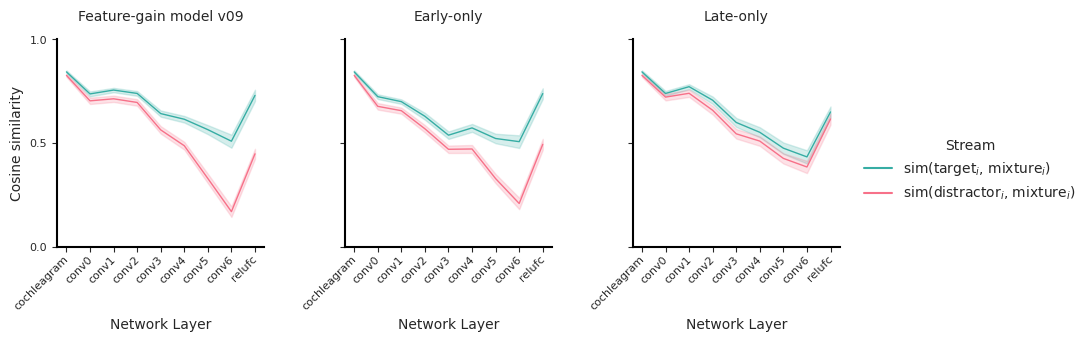

In [65]:
## Plot summary_results df 
sns.set_style('ticks')
# order = np.sort(results.layer.unique())
plt.rc('font', family='Helvetica')

hue_order = ['sim(target$_i$, mixture$_i$)', 'sim(distractor$_i$, mixture$_i$)', ]#'sim(target$_i$, target$_j$)', 'sim(target$_i$, mixture$_j$)']
# make palette for models in husl 
palette = sns.color_palette("husl", 2)
# make palette dict 
palette_dict = {'sim(target$_i$, mixture$_i$)': palette[1],
                'sim(distractor$_i$, mixture$_i$)': palette[0],
                'sim(target$_i$, target$_j$)': 'k',
                'sim(target$_i$, mixture$_j$)': 'grey'}

# add line style dict 
line_style_dict = {'sim(target$_i$, mixture$_i$)': '-',
                   'sim(distractor$_i$, mixture$_i$)': '-',
                   'sim(target$_i$, target$_j$)': '--',
                   'sim(target$_i$, mixture$_j$)': '--'}  

p = sns.relplot(kind='line', data=cos_results, 
                x='layer', y="Cosine similarity", #order=order,
                col = 'model_name', col_order=['Feature-gain model v09', 'Early-only', 'Late-only'],
                hue = 'Stream', hue_order = hue_order, palette=palette_dict, 
                height=3, aspect=1, 
            #   err_style='bars', err_kws={'elinewidth': 1},
                errorbar=('se', 2), seed=1)
            #   errorbar=('ci'), n_boot=10_000, seed=1)

fontsize=10
tick_fontsize = 8

p.set_axis_labels("Network Layer", "Cosine similarity", size=fontsize)
p.set_titles("{col_name}", size=fontsize, y=1.05)
# p.axes[0,0].xaxis.labelpad = -0.25
# set y limit to 0,1
p.set(ylim=(0,1))
# move x axis label up 


p.set_xticklabels(rotation=45, size=tick_fontsize,  ha='right', va='center_baseline',  rotation_mode='anchor')
    
# set first row x and y limits to 0 1
yticks = np.linspace(0,1,3).round(1)
ratio = 1.0
# increase axis thickness and set to square aspect

line_thickness = 1.5

for ax in p.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    ax.set_yticks(ticks=yticks) # set new labels
    ax.set_yticklabels(labels= yticks, fontsize=tick_fontsize)
    for line in ax.get_lines():
        line.set_linewidth(1)
        line.set_linestyle('-')
        line.set_alpha(1)
        # remove marker 

    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

# replace legend with text of stream names 
# p._legend.remove()
# # add text 
# p.fig.text(0.305, 0.9, 'sim(target$_i$, mixture$_i$)', fontsize=tick_fontsize, color=palette_dict['sim(target$_i$, mixture$_i$)'], ha='left');
# p.fig.text(0.305, 0.825, 'sim(distractor$_i$, mixture$_i$)', fontsize=tick_fontsize, color=palette_dict['sim(distractor$_i$, mixture$_i$)'], ha='left');

# plt.savefig(outfig_dest/'stage_of_selection_for_poster.pdf', transparent=True, bbox_inches='tight')



In [23]:
import matplotlib
matplotlib.rcParams['font.family']


['Helvetica']

In [52]:
import yaml 

config = yaml.safe_load(open('config/binaural_attn/word_task_early_only_v09.yaml', 'r'))

In [54]:
from src.spatial_attn_lightning import BinauralAttentionModule 

model = BinauralAttentionModule(config)

Using explicit dim specification for demeaning in audio transforms
Using BinauralAuditoryAttentionCNN
v08 True
num_classes={'num_words': 800}
Model performing word task
Using singe gain function per layer
Conv block order: LN -> Conv -> ReLU
fc_attn: False
coch_affine: True
center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


In [56]:
model.model

BinauralAuditoryAttentionCNN(
  (model_dict): ModuleDict(
    (norm_coch_rep): LayerNorm((2, 40, 20000), eps=1e-05, elementwise_affine=True)
    (attn0): SimpleAttentionalGain()
    (conv_block_0): Sequential(
      (0): LayerNorm((2, 40, 20000), eps=1e-05, elementwise_affine=True)
      (1): Conv2d(2, 32, kernel_size=(2, 34), stride=(1, 1), bias=False)
      (2): ReLU()
    )
    (hann_pool_0): HannPooling2d()
    (conv_block_1): Sequential(
      (0): LayerNorm((32, 20, 4992), eps=1e-05, elementwise_affine=True)
      (1): Conv2d(32, 64, kernel_size=(2, 14), stride=(1, 1), bias=False)
      (2): ReLU()
    )
    (hann_pool_1): HannPooling2d()
    (conv_block_2): Sequential(
      (0): LayerNorm((64, 10, 1245), eps=1e-05, elementwise_affine=True)
      (1): Conv2d(64, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 0), bias=False)
      (2): ReLU()
    )
    (hann_pool_2): HannPooling2d()
    (conv_block_3): Sequential(
      (0): LayerNorm((256, 10, 249), eps=1e-05, elementwise_a